# Prototype: Domain and Range Inclusion for Chained TrueMeasure Transformations

## Motivation

QMCPy already supports chained `TrueMeasure` transformations. The current compatibility check is based on exact equality between the previous transform's range and the next transform's domain.

Exact equality is stronger than necessary for determining whether two transformations are domain-compatible. A natural weaker condition is that every possible output of the previous transformation lies within the domain accepted by the next transformation.

This proof of concept investigates that narrow condition:

$$
\operatorname{range}(T_{j-1})
\subseteq
\operatorname{domain}(T_j).
$$

For this first step, domains and ranges are restricted to axis-aligned intervals or multidimensional boxes represented as NumPy arrays of shape `(d, 2)`.

This notebook only tests the proposed compatibility rule. It does **not** modify QMCPy source code or attempt to solve the broader transport-map problem.

## Mathematical formulation

In one dimension, let

$$R=[r_L,r_U], \qquad D=[d_L,d_U].$$

The previous range is compatible with the target domain exactly when

$$R\subseteq D \iff d_L\le r_L \quad\text{and}\quad r_U\le d_U.$$

For $d$ dimensions, define the axis-aligned boxes

$$R=\prod_{i=1}^{d}[r_i^L,r_i^U], \qquad D=\prod_{i=1}^{d}[d_i^L,d_i^U].$$

Then

$$R\subseteq D \iff d_i^L\le r_i^L \quad\text{and}\quad r_i^U\le d_i^U \quad\text{for every }i.$$

Numeric infinite bounds such as $[-\infty,\infty]$, $[0,\infty]$, and $[5,\infty]$ obey the same comparisons. Exact equality remains valid because equality is a special case of inclusion.

## Current check vs. proposed check

The conceptual change is small.

### Current behavior

The current compatibility logic effectively requires

$$
R = D.
$$

For example,

$$
[1,3] \neq [0,5],
$$

so an exact-equality check considers these different even though every point produced in $[1,3]$ is accepted by a transformation defined on $[0,5]$.

### Proposed behavior

Instead, check

$$
R \subseteq D.
$$

Therefore,

$$
[1,3] \subseteq [0,5]
$$

is compatible.

Equality remains valid automatically because

$$
R=D \implies R\subseteq D.
$$

The proposed change therefore generalizes the current rule rather than removing the existing equality case.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Standalone inclusion helper

Malformed or mismatched inputs return `False` in this demonstration. Whether production code should instead raise `ParameterError` is left as a design question.

In [24]:
def range_is_within_domain(transform_range, target_domain):
    """Return whether one axis-aligned box is contained in another."""
    transform_range = np.asarray(transform_range)
    target_domain = np.asarray(target_domain)

    if transform_range.ndim != 2 or transform_range.shape[1] != 2:
        return False
    if target_domain.ndim != 2 or target_domain.shape[1] != 2:
        return False
    if transform_range.shape != target_domain.shape:
        return False

    lower_bounds_fit = target_domain[:, 0] <= transform_range[:, 0]
    upper_bounds_fit = transform_range[:, 1] <= target_domain[:, 1]
    return bool(np.all(lower_bounds_fit & upper_bounds_fit))

## Diagnostic helper

The second helper returns structured details for discussion. Dimension numbers are one-based in its report.

In [25]:
def explain_domain_compatibility(transform_range, target_domain):
    """Explain coordinate-wise box compatibility and any failures."""
    transform_range = np.asarray(transform_range)
    target_domain = np.asarray(target_domain)
    valid_range_shape = transform_range.ndim == 2 and transform_range.shape[1] == 2
    valid_domain_shape = target_domain.ndim == 2 and target_domain.shape[1] == 2
    shapes_match = valid_range_shape and valid_domain_shape and (
        transform_range.shape == target_domain.shape
    )

    report = {
        "shapes_match": shapes_match,
        "transform_range": transform_range.tolist(),
        "target_domain": target_domain.tolist(),
        "failing_dimensions": [],
        "compatible": False,
    }
    if not shapes_match:
        report["reason"] = "Both arrays must have the same shape (d, 2)."
        return report

    for i, ((r_lower, r_upper), (d_lower, d_upper)) in enumerate(
        zip(transform_range, target_domain), start=1
    ):
        lower_fails = bool(d_lower > r_lower)
        upper_fails = bool(r_upper > d_upper)
        if lower_fails or upper_fails:
            report["failing_dimensions"].append({
                "dimension": i,
                "lower_bound_condition_fails": lower_fails,
                "upper_bound_condition_fails": upper_fails,
            })

    report["compatible"] = not report["failing_dimensions"]
    return report

## Test and demonstration cases

Each requested case is evaluated independently below, followed by a compact summary.

In [26]:
# Case A: exact equality
range_a = [[0, 1]]
domain_a = [[0, 1]]
range_is_within_domain(range_a, domain_a)

True

In [27]:
# Cases B and C: strict inclusion, including a half-line
range_b, domain_b = [[-1, 1]], [[-np.inf, np.inf]]
range_c, domain_c = [[1, 3]], [[0, np.inf]]
range_is_within_domain(range_b, domain_b), range_is_within_domain(range_c, domain_c)

(True, True)

In [28]:
# Cases D and E: lower- and upper-bound failures
range_d, domain_d = [[-1, 1]], [[0, np.inf]]
range_e, domain_e = [[1, 5]], [[0, 4]]
explain_domain_compatibility(range_d, domain_d), explain_domain_compatibility(range_e, domain_e)

({'shapes_match': True,
  'transform_range': [[-1, 1]],
  'target_domain': [[0.0, inf]],
  'failing_dimensions': [{'dimension': 1,
    'lower_bound_condition_fails': True,
    'upper_bound_condition_fails': False}],
  'compatible': False},
 {'shapes_match': True,
  'transform_range': [[1, 5]],
  'target_domain': [[0, 4]],
  'failing_dimensions': [{'dimension': 1,
    'lower_bound_condition_fails': False,
    'upper_bound_condition_fails': True}],
  'compatible': False})

In [29]:
# Cases F and G: valid and invalid 2D boxes
range_f = [[1, 3], [2, 5]]
domain_f = [[0, 4], [0, 10]]
range_g = [[1, 5], [2, 5]]
domain_g = [[0, 4], [0, 10]]
range_is_within_domain(range_f, domain_f), explain_domain_compatibility(range_g, domain_g)

(True,
 {'shapes_match': True,
  'transform_range': [[1, 5], [2, 5]],
  'target_domain': [[0, 4], [0, 10]],
  'failing_dimensions': [{'dimension': 1,
    'lower_bound_condition_fails': False,
    'upper_bound_condition_fails': True}],
  'compatible': False})

In [30]:
# Case H: a 3D box with infinite bounds
range_h = [[1, 3], [2, 5], [-np.inf, np.inf]]
domain_h = [[0, 4], [0, 10], [-np.inf, np.inf]]
range_is_within_domain(range_h, domain_h)

True

In [31]:
# Case I: a 1D range cannot be compared with a 2D domain
range_i = [[0, 1]]
domain_i = [[0, 1], [0, 1]]
explain_domain_compatibility(range_i, domain_i)

{'shapes_match': False,
 'transform_range': [[0, 1]],
 'target_domain': [[0, 1], [0, 1]],
 'failing_dimensions': [],
 'compatible': False,
 'reason': 'Both arrays must have the same shape (d, 2).'}

## Summary table

In [32]:
cases = [
    ("A: exact equality", range_a, domain_a, True),
    ("B: strict inclusion", range_b, domain_b, True),
    ("C: positive half-line", range_c, domain_c, True),
    ("D: lower-bound failure", range_d, domain_d, False),
    ("E: upper-bound failure", range_e, domain_e, False),
    ("F: valid 2D box", range_f, domain_f, True),
    ("G: one 2D dimension fails", range_g, domain_g, False),
    ("H: 3D with infinities", range_h, domain_h, True),
    ("I: shape mismatch", range_i, domain_i, False),
]

rows = []
for name, transform_range, target_domain, expected in cases:
    computed = range_is_within_domain(transform_range, target_domain)
    rows.append({
        "case name": name,
        "transform range": str(transform_range),
        "target domain": str(target_domain),
        "expected result": expected,
        "computed result": computed,
        "pass/fail": "PASS" if computed == expected else "FAIL",
    })

summary = pd.DataFrame(rows)
assert (summary["pass/fail"] == "PASS").all()
summary

,case name,transform range,target domain,expected result,computed result,pass/fail
0,A: exact equality,"[[0, 1]]","[[0, 1]]",True,True,PASS
1,B: strict inclusion,"[[-1, 1]]","[[-inf, inf]]",True,True,PASS
2,C: positive half-line,"[[1, 3]]","[[0, inf]]",True,True,PASS
3,D: lower-bound failure,"[[-1, 1]]","[[0, inf]]",False,False,PASS
4,E: upper-bound failure,"[[1, 5]]","[[0, 4]]",False,False,PASS
5,F: valid 2D box,"[[1, 3], [2, 5]]","[[0, 4], [0, 10]]",True,True,PASS
6,G: one 2D dimension fails,"[[1, 5], [2, 5]]","[[0, 4], [0, 10]]",False,False,PASS
7,H: 3D with infinities,"[[1, 3], [2, 5], [-inf, inf]]","[[0, 4], [0, 10], [-inf, inf]]",True,True,PASS
8,I: shape mismatch,"[[0, 1]]","[[0, 1], [0, 1]]",False,False,PASS


## One-dimensional visualization

The target domain is shown above the previous transform range. Inclusion succeeds on the left; on the right, the transform range extends below the domain's lower bound.

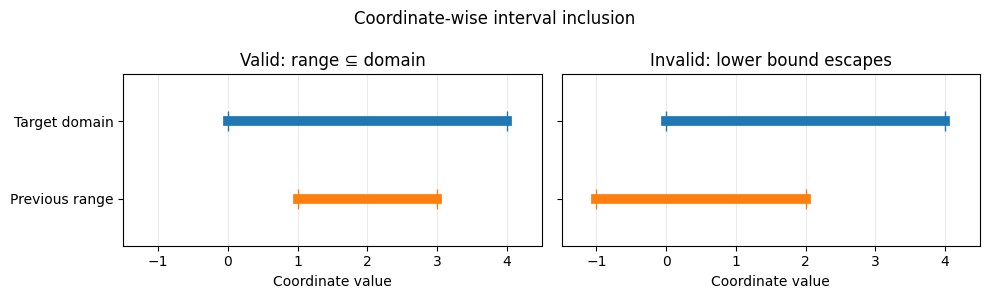

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
examples = [
    (axes[0], (0, 4), (1, 3), "Valid: range ⊆ domain"),
    (axes[1], (0, 4), (-1, 2), "Invalid: lower bound escapes"),
]

for ax, domain_interval, range_interval, title in examples:
    ax.plot(domain_interval, [1, 1], marker="|", markersize=14, linewidth=7, label="Target domain")
    ax.plot(range_interval, [0, 0], marker="|", markersize=14, linewidth=7, label="Previous range")
    ax.set_yticks([0, 1], ["Previous range", "Target domain"])
    ax.set_xlim(-1.5, 4.5)
    ax.set_ylim(-0.6, 1.6)
    ax.grid(axis="x", alpha=0.25)
    ax.set_title(title)
    ax.set_xlabel("Coordinate value")

fig.suptitle("Coordinate-wise interval inclusion")
fig.tight_layout()
plt.show()

## Multidimensional boxes

For axis-aligned boxes, no complicated geometric algorithm or 3D visualization is needed. The check decomposes into independent interval checks along each coordinate. For example,

$$[1,3]\times[2,5] \subseteq [0,4]\times[0,10]$$

because $[1,3]\subseteq[0,4]$ in the first coordinate and $[2,5]\subseteq[0,10]$ in the second. One failing coordinate makes the entire box incompatible.

## How this would connect to QMCPy

Conceptually, the current exact-equality logic in `AbstractTrueMeasure._parse_sampler` could later be replaced by logic equivalent to the following. This is **pseudocode for discussion, not a source edit**:

```python
if not range_is_within_domain(
    self.transform.range,
    self.domain,
):
    self.sub_compatibility_error = True
```

A production change would still need to follow QMCPy's error conventions, array normalization rules, and existing test expectations.

## Questions before production implementation

- Should malformed shapes raise `ParameterError` instead of returning `False`?
- Should domain/range arrays always be normalized to shape `(d, 2)`?
- Should containment be checked only when chaining two `TrueMeasure` objects, or should the same compatibility rule apply anywhere QMCPy compares transformation domains and ranges?
- Do we need to distinguish open and closed bounds in the future?
- Should compatibility logic live in `AbstractTrueMeasure` or a utility function?
- Should we add a reusable box/support abstraction later?
- What existing `TrueMeasure` tests need to be preserved?

## Conclusion

This prototype demonstrates that exact equality can be generalized to coordinate-wise interval inclusion with very little mathematical or computational complexity, while keeping the first implementation narrow.